# Intro

- Recoding of https://github.com/Daniel-EST/deep-steganography/ but updated to match modern tensorflow or pytorch depending what is easiest to use
- from paper: 500 training images, 50 validation images, and 50 test images, all uniformly resized to a manageable dimension of 64x64x3 pixels
    - with rbg colour (no greyscale) to ease training

- overall process:
  - get text which is small enough *after* huffman encoding to fit within 64*64*3 sized block, and encode within image using LSB resulting in **secret image** which will be used by NN (for training all will be encoded with *"Hello World!"* just to keep things simple, but randomized text could be more authentic)
    - LSB - use pillow library (https://pypi.org/project/pillow/) to ease implementation
    - Huffman will also be from GeeksForGeeks / public implementation to speed development
  - NN will be three layers a preperation > hide > reveal networks (with each being NNs) that will ideally allow for full reconstruction of secret image
  - finally undo LSB + Huffman to retrieve final text and check accordingly.

- Issues so far:
  - Deep stenography is greatly outdated so fixing has not been very easy, could promp re-scope of assign to meet deadline if it is unable to be done
  - reformatting between secret image > steg image > revealed secret causes issues with LSB where unless its 100% (>90% ssim) then final classical steganography cannot be performed often
  - could add scheduler to improve flattening learning rate after x epochs and this could benefit the issues with too much noise ruining secret text recovery.

In [1]:
from LSB_Steganography.LSBSteg import LSBSteg
from dahuffman import HuffmanCodec

# code example from https://github.com/RobinDavid/LSB-Steganography libraru, lsb is using
# LSB 
def LSBEmbed(text,image):
    # Embed text into image using least sig bit method
    steg = LSBSteg(image)
    img_encoded = steg.encode_binary(text)
    return img_encoded

def LSBExtract(image):
    # pull least sig bit from image and reformat into embedded text
    steg = LSBSteg(image)
    extracted_text = steg.decode_binary()
    return extracted_text

# huffman serialization assisted with chatgpt for debugging, dahuffman use from PyPl example
def HuffmanEncode(data):
    # encode text into huffman tree + map
    codec = HuffmanCodec.from_data(data)
    encoded_data = codec.encode(data)

    # finally prepend all so tree:data is one block
    return codec, encoded_data

def HuffmanDecode(codec,data):
    # using Huffman map reconstruct text to original values and decode / unzip data
    decoded_data = codec.decode(data)
    return decoded_data

In [2]:
from datasets import load_dataset
import os, certifi
import numpy as np
import tensorflow as tf

os.environ['SSL_CERT_FILE'] = certifi.where()
def is_rgb(example):
    return example['image'].mode == 'RGB'
# option 1 uses "Hello World!" for all to reuse codec and make things simpler
temp_data = load_dataset("zh-plus/tiny-imagenet")
tiny_imageNet_rgb = temp_data.filter(is_rgb)

# comment out select for whole dataset, just to test set to 1/4
train_pool = tiny_imageNet_rgb['train']#.select(range(25000))
test_pool = tiny_imageNet_rgb['valid']

ex_data = "Hello World!"
codec,encoded_data = HuffmanEncode(ex_data)

# 2. Sample from Training Pool
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def create_tfrecord(dataset_pool, output_path):
    with tf.io.TFRecordWriter(output_path) as writer:
        for i in range(len(dataset_pool)):
            # Pair cover (i) and secret (i+1) as per your logic
            cover_idx = i
            secret_idx = (i + 1) % len(dataset_pool)
            
            # Process cover image
            c_img = dataset_pool[cover_idx]['image'].convert('RGB').resize((64, 64))
            
            # Process secret image with LSB
            s_img_raw = dataset_pool[secret_idx]['image'].convert('RGB').resize((64, 64))
            s_steg = LSBEmbed(encoded_data, np.array(s_img_raw)) # Using your LSB function
            
            # Serialize
            feature = {
                'cover': _bytes_feature(np.array(c_img).tobytes()),
                'secret': _bytes_feature(np.array(s_steg).tobytes())
            }
            example = tf.train.Example(features=tf.train.Features(feature=feature))
            writer.write(example.SerializeToString())

# Run for train and test
create_tfrecord(train_pool, 'train_data.tfrecords')

def parse_function(example_proto):
    feature_description = {
        'cover': tf.io.FixedLenFeature([], tf.string),
        'secret': tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    
    # Decode and normalize to [0, 1]
    cover = tf.io.decode_raw(parsed['cover'], tf.uint8)
    cover = tf.reshape(cover, [64, 64, 3])
    cover = tf.cast(cover, tf.float32) / 255.0
    
    secret = tf.io.decode_raw(parsed['secret'], tf.uint8)
    secret = tf.reshape(secret, [64, 64, 3])
    secret = tf.cast(secret, tf.float32) / 255.0
    
    return cover, secret

def preprocess_and_embed(image):
    # 1. Resize and convert to RGB as per paper
    image = image.convert('RGB').resize((64, 64))
    np_img = np.array(image).astype('float32')
    
    # 2. Apply LSB Embedding from your code
    # Note: Secret image is created by embedding text into a cover image 
    # as described in the paper's multi-layered approach
    secret_steg = LSBEmbed(encoded_data, np_img.astype('uint8'))
    
    # 3. Normalize for the Neural Network
    return np_img / 255.0, np.array(secret_steg).astype('float32') / 255.0

def test_generator():
    # Stream from the full 100,000 image pool
    for i in range(len(test_pool)):
        # Get random pairs for cover and secret as intended in notebook
        cover_idx = i
        secret_idx = (i + 1) % len(train_pool)
        
        c_img, _ = preprocess_and_embed(test_pool[cover_idx]['image'])
        _, s_img = preprocess_and_embed(test_pool[secret_idx]['image'])
        
        yield (c_img, s_img)

# Create the streaming dataset
test_dataset = tf.data.Dataset.from_generator(
    test_generator,
    output_signature=(
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)

print(f"Pools Ready: {len(train_pool)/2} Train pairs, {len(test_pool)/2} Test pairs.")

I0000 00:00:1773604581.581906    1319 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Pools Ready: 49089.5 Train pairs, 4916.0 Test pairs.


I0000 00:00:1773604690.834054    1319 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [3]:
from tensorflow.keras import layers, losses
tf.keras.backend.clear_session()
class SteganoModel(tf.keras.Model):
    def __init__(self):
        super(SteganoModel, self).__init__()
        self.beta = 1
        
        # 1. PREP NETWORK: (None, 64, 64, 3) -> (None, 64, 64, 150)
        # Using 50 filters of each size (3x3, 4x4, 5x5) to reach 150
        self.prep_conv3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')
        self.prep_conv4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu')
        self.prep_conv5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu')

        # 2. HIDE NETWORK: (None, 64, 64, 150+3) -> (None, 64, 64, 3)
        self.hide_conv1 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')
        self.hide_conv2 = layers.Conv2D(10, (3, 3), padding='same', activation='relu')
        self.hide_conv3 = layers.Conv2D(5, (3, 3), padding='same', activation='relu')
        self.hide_final = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')

        # 3. REVEAL NETWORK: (None, 64, 64, 3) -> (None, 64, 64, 3)
        self.reveal_conv1 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')
        self.reveal_conv2 = layers.Conv2D(10, (3, 3), padding='same', activation='relu')
        self.reveal_conv3 = layers.Conv2D(5, (3, 3), padding='same', activation='relu')
        self.reveal_final = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')

    def hide(self, secret, cover):
        # Prep
        p3 = self.prep_conv3(secret)
        p4 = self.prep_conv4(secret)
        p5 = self.prep_conv5(secret)
        prep_out = tf.concat([p3, p4, p5], axis=-1) # 150 channels
        
        # Hide
        merged = tf.concat([prep_out, cover], axis=-1) # 153 channels
        x = self.hide_conv1(merged)
        x = self.hide_conv2(x)
        x = self.hide_conv3(x)
        return self.hide_final(x)

    def reveal(self, stego):
        x = self.reveal_conv1(stego)
        x = self.reveal_conv2(x)
        x = self.reveal_conv3(x)
        return self.reveal_final(x)

    def call(self, inputs):
        cover, secret = inputs
        stego = self.hide(secret, cover)
        extracted = self.reveal(stego)
        return stego, extracted

    def train_step(self, data):
        # Unpack the data (Expecting cover and secret images)
        cover, secret = data

        with tf.GradientTape() as tape:
            stego, extracted = self((cover, secret), training=True)
            
            # Loss Calculation: total_loss = cover_mse + beta * secret_mse
            cover_mse = tf.reduce_mean(losses.mse(cover, stego))
            secret_mse = tf.reduce_mean(losses.mse(secret, extracted))
            total_loss = cover_mse + (self.beta * secret_mse)

        # Apply gradients
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(total_loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        
        return {"loss": total_loss, "cover_mse": cover_mse, "secret_mse": secret_mse}

# Initialize
model = SteganoModel()

In [4]:
import time, math
# --- Training Configuration ---
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))

train_ds = tf.data.TFRecordDataset('train_data.tfrecords') \
    .map(parse_function,num_parallel_calls=tf.data.AUTOTUNE) \
        .shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

start_time = time.time()
history = model.fit(
    train_ds, 
    epochs=EPOCHS,
    steps_per_epoch=(math.floor(len(train_pool)/BATCH_SIZE)) 
)
end_time = time.time()
total_time = end_time - start_time
print("Training Complete.")
print(f"total time: {total_time}, time/epoch: {total_time/EPOCHS}")

Epoch 1/100


I0000 00:00:1773604694.697038    1424 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
I0000 00:00:1773604694.768433    1401 service.cc:153] XLA service 0x7f3d84039830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773604694.768488    1401 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650 with Max-Q Design, Compute Capability 7.5 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773604694.842250    1401 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773604695.358304    1401 cuda_dnn.cc:461] Loaded cuDNN version 92000
E0000 00:00:1773604697.058688    1401 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773604704.455908    1401 device_compiler.h:208] C

3068/3068 ━━━━━━━━━━━━━━━━━━━━ 218s 67ms/step - cover_mse: 0.0108 - loss: 0.0206 - secret_mse: 0.0098
Epoch 2/100


E0000 00:00:1773604916.661503    1404 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3068/3068 ━━━━━━━━━━━━━━━━━━━━ 16s 11us/step - cover_mse: 0.0047 - loss: 0.0109 - secret_mse: 0.0062    
Epoch 3/100


...

I0000 00:00:1773613733.678593    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16306949037562867359
I0000 00:00:1773613733.678715    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15941534338182740790


3068/3068 ━━━━━━━━━━━━━━━━━━━━ 185s 60ms/step - cover_mse: 0.0024 - loss: 0.0055 - secret_mse: 0.0031
Epoch 98/100
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step - cover_mse: 0.0013 - loss: 0.0092 - secret_mse: 0.0079  
Epoch 99/100
   1/3068 ━━━━━━━━━━━━━━━━━━━━ 9:37 188ms/step - cover_mse: 0.0036 - loss: 0.0076 - secret_mse: 0.0041

I0000 00:00:1773613918.894362    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16306949037562867359
I0000 00:00:1773613918.894585    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15941534338182740790


3068/3068 ━━━━━━━━━━━━━━━━━━━━ 186s 61ms/step - cover_mse: 0.0018 - loss: 0.0048 - secret_mse: 0.0031
Epoch 100/100
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step - cover_mse: 0.0102 - loss: 0.0144 - secret_mse: 0.0042  
Training Complete.
total time: 9413.447015285492, time/epoch: 94.13447015285492


I0000 00:00:1773614104.857329    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16306949037562867359
I0000 00:00:1773614104.857467    1455 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15941534338182740790


In [5]:
# Save the whole model weights
model.save('steganography_model.keras')

# so that reveal is seperate?
# 1. Define a fresh input for the standalone decoder
decoder_input = tf.keras.Input(shape=(64, 64, 3), name='stego_input_only')

# 2. Extract the reveal logic from your trained model
# We pass the new input through the reveal_layer of the existing 'model'
decoder_output = model.reveal(decoder_input)

# 3. Create the separate model
reveal_model = tf.keras.models.Model(inputs=decoder_input, outputs=decoder_output)

# 4. Compile and Save
reveal_model.compile(optimizer='adam', loss='mse')
reveal_model.save('standalone_reveal.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Extraction failed due to: No available slot remaining (image filled)
Metrics for Secret vs Revealed:
PSNR: 24.98 dB
SSIM: 0.8719
AccTxt: 0.0000


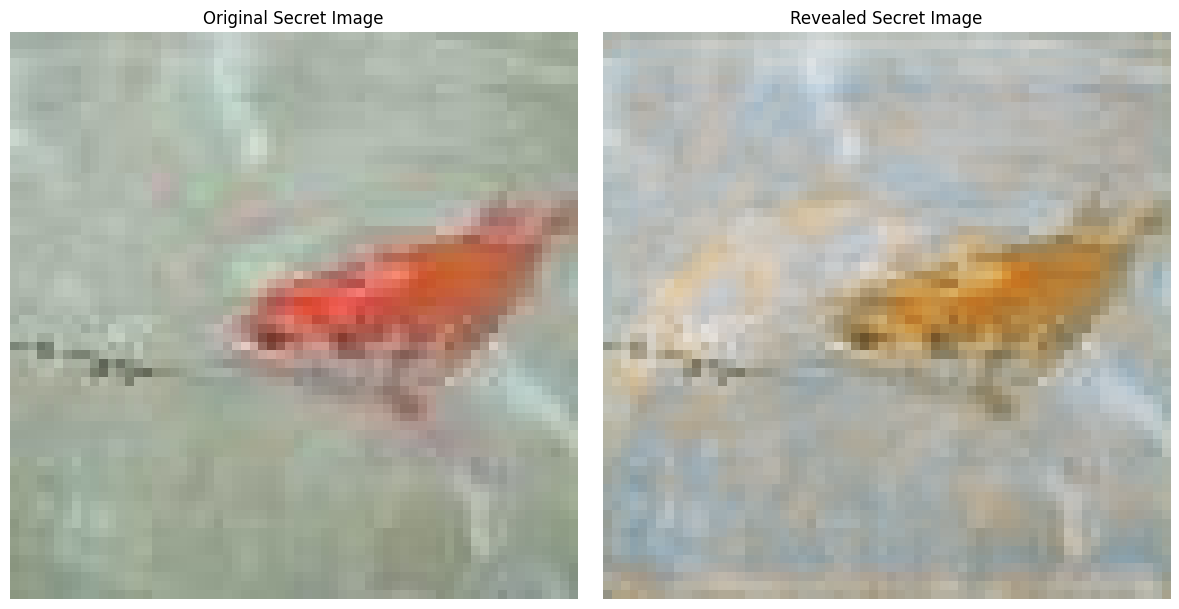

In [7]:
import matplotlib.pyplot as plt

def calculate_metrics(img1, img2):
    # Ensure inputs are tensors
    img1 = tf.convert_to_tensor(img1)
    img2 = tf.convert_to_tensor(img2)
    
    # If the images don't have a batch dimension (shape H,W,C), add one
    if len(img1.shape) == 3:
        img1 = tf.expand_dims(img1, axis=0)
    if len(img2.shape) == 3:
        img2 = tf.expand_dims(img2, axis=0)

    # Calculate metrics
    psnr = tf.image.psnr(img1, img2, max_val=1.0)
    ssim = tf.image.ssim(img1, img2, max_val=1.0)
    
    # .numpy() now returns an array, so [0] will work correctly
    return psnr.numpy()[0], ssim.numpy()[0]

def AccTxt(original_txt,recovered_txt):
    T = len(original_txt)

    D = 0

    for i in original_txt:
        if original_txt[i] == recovered_txt[i]:
            D+=1
    
    return D/T*100

for cover, secret in test_dataset.batch(10).take(1):
    stego, revealed = model.predict([cover,secret])

    final_acc = 0.0
    try:
        revealed_uint8 = (revealed[0] * 255).astype(np.uint8)
        # 2. Extract binary data using your LSBExtract function
        extracted_bin = LSBExtract(revealed_uint8)

        # 3. Decode Huffman
        # Note: 'codec' must be the one created during training
        final_text = HuffmanDecode(codec, extracted_bin)
        print(f"recovered text: {final_text}")
        final_acc = AccTxt(final_text)
    except Exception as e:
        print(f"Extraction failed due to: {e}")

    # 3. Print quantitative metrics for context
    psnr_val, ssim_val = calculate_metrics(secret[0],revealed[0])

    print(f"Metrics for Secret vs Revealed:")
    print(f"PSNR: {psnr_val:.2f} dB")
    print(f"SSIM: {ssim_val:.4f}")
    print(f"AccTxt: {final_acc:.4f}")
    plt.figure(figsize=(12, 6))

    # Original Secret Image
    plt.subplot(1, 2, 1)
    plt.title("Original Secret Image")
    plt.imshow(secret[0])
    plt.axis('off')

    # Revealed Secret Image
    plt.subplot(1, 2, 2)
    plt.title("Revealed Secret Image")
    plt.imshow(revealed[0])
    plt.axis('off')

    plt.tight_layout()
    plt.show()